In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruit-and-vegetable-image-recognition' dataset.
Path to dataset files: /kaggle/input/fruit-and-vegetable-image-recognition


In [ ]:
import os
os.listdir(path)

['validation', 'test', 'train']

In [ ]:
os.listdir(path+"/train")

['capsicum',
 'sweetcorn',
 'orange',
 'tomato',
 'turnip',
 'ginger',
 'raddish',
 'pomegranate',
 'pineapple',
 'jalepeno',
 'apple',
 'carrot',
 'lettuce',
 'bell pepper',
 'eggplant',
 'beetroot',
 'kiwi',
 'pear',
 'cabbage',
 'cauliflower',
 'paprika',
 'lemon',
 'sweetpotato',
 'grapes',
 'cucumber',
 'corn',
 'banana',
 'garlic',
 'chilli pepper',
 'watermelon',
 'mango',
 'peas',
 'onion',
 'potato',
 'spinach',
 'soy beans']

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the generator (and any data augmentation)
datagen = ImageDataGenerator(rescale=1./255)

# 2. Define your parameters (make sure these are set!)
img_size = 224
batch_size = 32

# 3. Now your code will work
train_data = datagen.flow_from_directory(
    path + "/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)
val_data=datagen.flow_from_directory(
    path+"/validation",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.


LABELS FRUITS AND VEGETABLES

In [ ]:
fruit_classes=['Banana', 'Apple', 'Pear', 'Grapes', 'Orange', 'Kiwi', 'Watermelon',
               'Pomegranate', 'Pineapple', 'Mango'

]
class_names=list(train_data.class_indices.keys())
def classify_type(class_name):
  if class_name.lower() in [f.lower() for f in fruit_classes]:
        return "Fruit"
  else:
        return "Vegetable"

BULID CNN

In [ ]:
from tensorflow.keras import models, layers, Input

img_size = 224 # Matches train_data target_size

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Now run the fit
model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
10/98 ━━━━━━━━━━━━━━━━━━━━ 1:35 1s/step - accuracy: 0.0177 - loss: 3.6794

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.0584 - loss: 3.4195 - val_accuracy: 0.1140 - val_loss: 3.0640
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 899ms/step - accuracy: 0.1268 - loss: 3.0228 - val_accuracy: 0.2051 - val_loss: 2.6785
Epoch 3/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 904ms/step - accuracy: 0.2032 - loss: 2.6753 - val_accuracy: 0.3590 - val_loss: 2.0930
Epoch 4/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 901ms/step - accuracy: 0.3124 - loss: 2.2881 - val_accuracy: 0.4900 - val_loss: 1.6328
Epoch 5/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 92s 939ms/step - accuracy: 0.4019 - loss: 1.9757 - val_accuracy: 0.6154 - val_loss: 1.2786
Epoch 6/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 90s 919ms/step - accuracy: 0.4899 - loss: 1.6858 - val_accuracy: 0.7123 - val_loss: 1.0462
Epoch 7/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 897ms/step - accuracy: 0.5717 - loss: 1.4170 - val_accuracy: 0.7379 - val_loss: 0.9214
Epoch 8/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 89s 912ms/step - accuracy: 0.6543 - loss: 1.1410 - val_accuracy: 0.8091 

## upload a new image TO FIND THE CATEGORY

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,335,342 (58.50 MB)

 Trainable params: 5,111,780 (19.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,223,562 (39.00 MB)

Saving Image_4.jpg to Image_4 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Item: banana
Category: Fruit


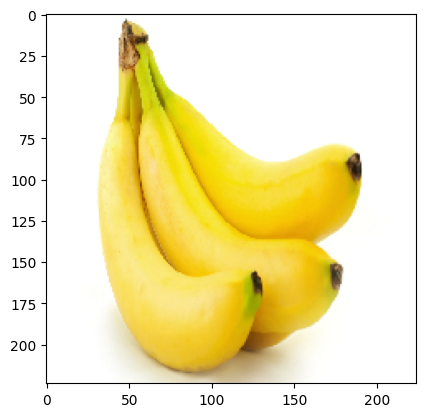

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# upload a new image
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

for img_name in uploaded.keys():
  img = image.load_img(img_name, target_size=(224, 224))
  plt.imshow(img)
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

  pred = model.predict(img_array)
   # Getting the specific class name from the generator's dictionary
  class_idx = np.argmax(pred)
  predicted_class_name = class_names[class_idx]

  # Using your logic function from earlier
  label = classify_type(predicted_class_name)

  print(f"Item: {predicted_class_name}")
  print(f"Category: {label}")

